<a href="https://colab.research.google.com/github/LuchoMarque/REDES-NEURONALES-LAB-A-parte-C/blob/main/laboratorio_1c.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Imgur](https://i.imgur.com/acSOZRh.png)

# Laboratorio n° 1. Parte C: Denoising Autoencoder

**Asignatura:** Redes Neuronales Profundas
**Bloque:** 1 — Fundamentos de Deep Learning

---

## Introducción

En este laboratorio vas a construir un **denoising autoencoder**: una red neuronal que aprende a eliminar ruido de imágenes.

Este ejercicio integra todos los conceptos vistos en los laboratorios anteriores: creación de modelos con `nn.Sequential`, loops de entrenamiento y evaluación de redes.

---

## Instrucciones generales

- Las celdas de **setup** ya están escritas — ejecutálas sin modificar.
- Completá el código en las celdas marcadas con `# Tu código aquí`.
- Respondé las preguntas de análisis en las celdas de texto.

---
## Ejercicios

### ¿Qué es un autoencoder?

Imaginá que tenés que fotocopiar un documento, pero la fotocopiadora agrega ruido (manchas, rayaduras). ¿Podría una red neuronal aprender a "limpiar" las fotocopias recibiendo como entrada la copia sucia y comparando la salida con el original?

Sí, y esa es exactamente la idea de un **denoising autoencoder** (autocodificador de eliminación de ruido).

Un autoencoder tiene dos partes:

```
imagen ruidosa → [ ENCODER ] → vector latente → [ DECODER ] → imagen reconstruida
```

![Imgur](https://i.imgur.com/iOp5Vdu.png)

**El Encoder** comprime la imagen en un vector de menor dimensión llamado **espacio latente**. La idea es que ese vector capture solo la información esencial de la imagen (la prenda, su forma, su textura), descartando el ruido, que es aleatorio y no tiene estructura.

**El Decoder** toma ese vector comprimido y reconstruye la imagen original sin ruido.

La red se entrena con la siguiente lógica:
- **Entrada:** imagen con ruido
- **Salida esperada (etiqueta):** imagen **sin** ruido
- **Función de pérdida:** error cuadrático medio (MSE) entre la imagen reconstruida y la original

Al minimizar ese error, la red aprende a comprimir solo la información relevante y a ignorar el ruido.

#### Setup — importaciones y datos

Fijamos `torch.manual_seed(42)` para reproducibilidad: garantiza los mismos resultados en cada ejecución (misma inicialización de pesos, mismo orden de datos en el *shuffle*).

Utilizaremos nuevamente el dataset FashionMNIST. Sabemos que este dataset tiene etiquetas de clase (prenda de ropa), pero en este laboratorio las **ignoramos** — se representan con `_` al iterar. La "etiqueta" aquí son las propias imágenes originales sin ruido.

In [6]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils import data
import matplotlib.pyplot as plt

torch.manual_seed(42)
batch_size = 256

mnist_train = torchvision.datasets.FashionMNIST(
    root="./data", train=True, transform=transforms.ToTensor(), download=True
)
mnist_test = torchvision.datasets.FashionMNIST(
    root="./data", train=False, transform=transforms.ToTensor(), download=True
)

# shuffle=True: mezcla los lotes en cada época para mejorar la generalización.
iter_train = data.DataLoader(mnist_train, batch_size, shuffle=True)
iter_valid = data.DataLoader(mnist_test, batch_size, shuffle=False)

print(f"PyTorch {torch.__version__}")
print(f"Entrenamiento: {len(mnist_train)} imágenes | Prueba: {len(mnist_test)} imágenes")

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 306kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.58MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.4MB/s]

PyTorch 2.10.0+cpu
Entrenamiento: 60000 imágenes | Prueba: 10000 imágenes


#### Generador de ruido de Dropout

Usamos `nn.Dropout(p=0.5)` como generador de ruido: con esa probabilidad, apaga (pone en 0) cada píxel de la imagen al azar. El efecto visual es que la mitad de los píxeles se vuelven negros.

> **Importante:** `nn.Dropout` solo actúa en modo entrenamiento (`.train()`). En modo evaluación (`.eval()`), el autoencoder **no modifica** la imagen. Esto es el comportamiento deseado: en producción las imágenes ya llegan limpias y deben pasar sin alteración.

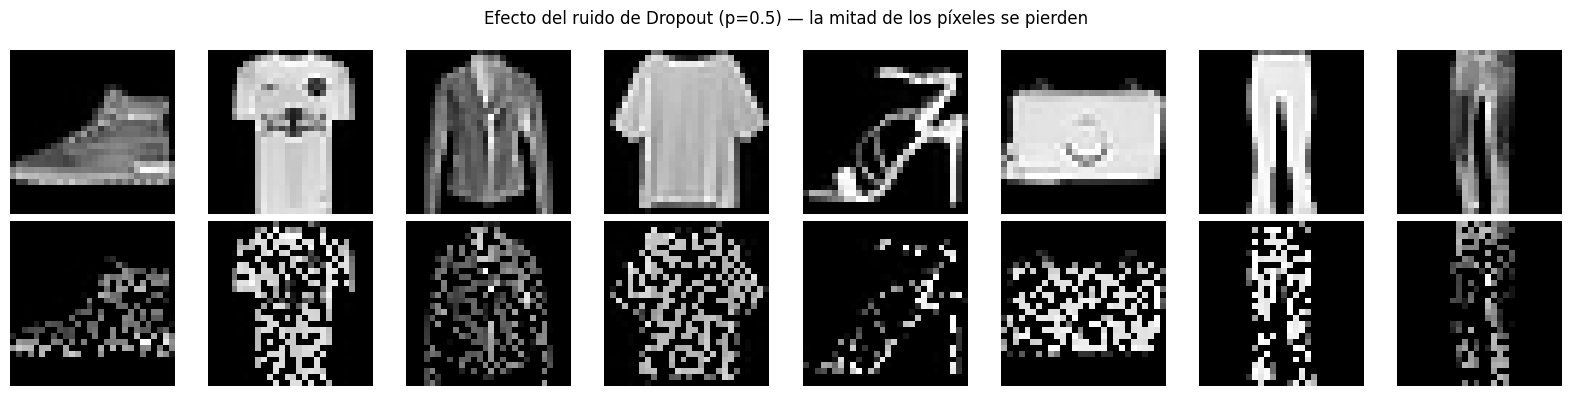

In [13]:
p = 0.5
noise = nn.Sequential(nn.Dropout(p))

images, _ = next(iter(iter_train))
noise.train()  # Dropout solo actúa en modo train
noise_images = noise(images)

n = 8
fig, axes = plt.subplots(2, n, figsize=(n * 2, 4))
for i in range(n):
    axes[0, i].imshow(images[i].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].imshow(noise_images[i].squeeze(), cmap="gray")
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("Con ruido", fontsize=12)
plt.suptitle("Efecto del ruido de Dropout (p=0.5) — la mitad de los píxeles se pierden")
plt.tight_layout()
plt.show()

### Ejercicio 1 — Construir el Encoder

**Objetivo:** Definir la mitad "compresora" del autoencoder.

**Enunciado:**

El encoder debe:
1. Tomar como entrada una imagen de 28×28 píxeles (aplanada en un vector de 784 elementos).
2. Pasarla por una capa oculta de **100 neuronas** con activación ReLU.
3. Producir un vector latente de **30 elementos**.

Guardá el encoder en la variable `encoder`.

> **Pista:** Usá `nn.Sequential` con las capas en orden: `Flatten → Linear(784, 100) → ReLU → Linear(100, 30)`

In [7]:

import torch.nn as nn
encoder = nn.Sequential(
    nn.Flatten(),          # Aplana la imagen de 28x28 a un vector de 784
    nn.Linear(784, 100),   #
    nn.ReLU(),             # Activación ReLU
    nn.Linear(100, 30)     # Capa de salida del encoder con 30 elementos
)

In [8]:
# Test automático del encoder — ejecutar sin modificar
images, _ = next(iter(iter_train))
try:
    latentes = encoder(images)
    assert latentes.shape[1] == 30, f"La salida del encoder debería tener 30 elementos, tiene {latentes.shape[1]}"
    print(f"Encoder OK: entrada {images.shape} -> latentes {latentes.shape}")
except Exception as e:
    print(f"Error: {e}")

Encoder OK: entrada torch.Size([256, 1, 28, 28]) -> latentes torch.Size([256, 30])


**Pregunta de análisis:**

¿Por qué es necesaria la activación ReLU entre las dos capas lineales del encoder? ¿Qué pasaría si la quitáramos?


La activación ReLU es necesaria para introducir no linealidad. Sin ella, la red se reduciría matemáticamente a una única capa lineal, limitando su capacidad a una simple proyección. Al quitarla, el modelo perdería la potencia necesaria para aprender y reconstruir patrones complejos en las imágenes.

### Ejercicio 2 — Construir el Decoder

**Objetivo:** Definir la mitad "reconstructora" del autoencoder.

**Enunciado:**

El decoder es el proceso inverso del encoder:
1. Recibe como entrada el vector latente de **30 elementos**.
2. Lo expande a través de una capa oculta de **100 neuronas** con activación ReLU.
3. Produce como salida una imagen reconstruida de **28×28** píxeles.

Guardá el decoder en la variable `decoder`.



In [9]:

decoder = nn.Sequential(
    nn.Linear(30, 100),    # Recibe el vector latente de 30 y expande a 100
    nn.ReLU(),             # Activación ReLU
    nn.Linear(100, 784),   # Expande de 100 a 784 (28*28 píxeles)
    nn.Unflatten(1, (28, 28)) # Reformatea el vector de 784 a una matriz de 28x28
)

In [10]:
# Test automático del decoder — ejecutar sin modificar
try:
    salidas = decoder(latentes)
    assert salidas.shape[1] == 28 and salidas.shape[2] == 28, \
        f"La salida del decoder debería ser (batch, 28, 28), es {salidas.shape}"
    print(f"Decoder OK: latentes {latentes.shape} -> salida {salidas.shape}")
except Exception as e:
    print(f"Error: {e}")

Decoder OK: latentes torch.Size([256, 30]) -> salida torch.Size([256, 28, 28])


### Ejercicio 3 — Ensamblar el Autoencoder

**Objetivo:** Conectar el generador de ruido, el encoder y el decoder en una única red.

**Enunciado:**

El autoencoder completo debe encadenar (`nn.Sequential`) los tres bloques en orden:
```
imagen → [noise] → [encoder] → [decoder] → imagen reconstruida
```

Guardalo en la variable `net_ae`.



In [14]:

net_ae = nn.Sequential(
    nn.Dropout(p=0.5),
    encoder,
    decoder
)

In [15]:
# Test automático del autoencoder — ejecutar sin modificar
try:
    net_ae.train()
    salida_ae = net_ae(images)
    assert salida_ae.shape == images[:, 0].shape, \
        f"La salida debería ser (batch, 28, 28), es {salida_ae.shape}"
    print(f"Autoencoder OK: entrada {images.shape} -> salida {salida_ae.shape}")
except Exception as e:
    print(f"Error: {e}")

Autoencoder OK: entrada torch.Size([256, 1, 28, 28]) -> salida torch.Size([256, 28, 28])


**Pregunta de análisis:**

El bloque `noise` corrompe la imagen antes de pasarla al encoder. Sin embargo, la función de pérdida compara la salida del decoder con la imagen **original** (sin ruido). ¿Por qué esta asimetría es la clave para que la red aprenda a eliminar ruido?

*(La asimetría es clave porque obliga a la red a no limitarse a copiar la entrada. Al comparar el resultado con la imagen limpia, el autoencoder aprende a identificar los patrones esenciales del objeto y a ignorar el ruido, actuando como un filtro que "rellena" la información faltante basándose en la estructura real de los datos.)*

### Ejercicio 4 — Definir pérdida y optimizador

**Objetivo:** Elegir la función de pérdida adecuada para un autoencoder.

**Enunciado:**

1. Instanciá la pérdida `nn.MSELoss()` y guardála en `loss_ae`.
2. Instanciá el optimizador `torch.optim.Adam(net_ae.parameters())` y guardálo en `trainer_ae`.

In [16]:
loss_ae = nn.MSELoss()
trainer_ae = torch.optim.Adam(net_ae.parameters(), lr=0.001)

**Pregunta de análisis:**

1. ¿Por qué usamos `MSELoss` y no `CrossEntropyLoss` para el autoencoder? ¿Cuál es la diferencia conceptual entre ambas?
2. Adam es un optimizador más sofisticado que SGD. ¿Qué ventaja tiene sobre SGD puro?

1. MSELoss vs CrossEntropyLoss:
Usamos MSELoss porque estamos ante un problema de regresión de píxeles (queremos que el valor numérico de salida sea lo más parecido al original). CrossEntropyLoss se usa para clasificación (probabilidades de pertenecer a una categoría), lo cual no aplica aquí ya que buscamos reconstruir una intensidad de imagen, no etiquetarla.

2. Ventaja de Adam sobre SGD:
La principal ventaja de Adam es que utiliza un learning rate adaptativo para cada parámetro y tiene en cuenta el "momento". Esto permite que converja mucho más rápido y sea menos sensible a la elección del valor inicial del learning rate comparado con un SGD puro, que usa un paso fijo para todo.

### Ejercicio 5 — Entrenar el autoencoder

**Objetivo:** Implementar el loop de entrenamiento para el autoencoder.

**Enunciado:**

Este bucle es similar al del Laboratorio 1b, con una diferencia importante: **la etiqueta no son clases, sino las imágenes originales sin ruido**. El objetivo es que la salida del modelo se parezca a la imagen de entrada.

1. Poné el modelo en modo entrenamiento (`net_ae.train()`)
2. Para cada lote `(images, _)` del `iter_train`:
   - Calculá la pérdida entre `net_ae(images)` y las imágenes originales.
   - **Atención con las formas:** `images` del DataLoader tiene forma `(B, 1, 28, 28)`. Si tu decoder termina en `nn.Linear`, la salida es `(B, 784)` y tenés que comparar contra `images.view(-1, 784)`. Si termina en `nn.Unflatten(1, (28, 28))`, la salida es `(B, 28, 28)` y comparás contra `images.squeeze(1)`.
   - Seguí los 4 pasos: `zero_grad → backward → step`
3. Entrenás por **50 épocas** (puede tardar unos minutos).
4. Visualizá las imágenes reconstruidas con la función `plot_reconstructions` provista abajo.


epoch 5/50 - Loss: 0.0127
epoch 10/50 - Loss: 0.0126
epoch 15/50 - Loss: 0.0126
epoch 20/50 - Loss: 0.0126
epoch 25/50 - Loss: 0.0126
epoch 30/50 - Loss: 0.0125
epoch 35/50 - Loss: 0.0125
epoch 40/50 - Loss: 0.0125
epoch 45/50 - Loss: 0.0125
epoch 50/50 - Loss: 0.0125


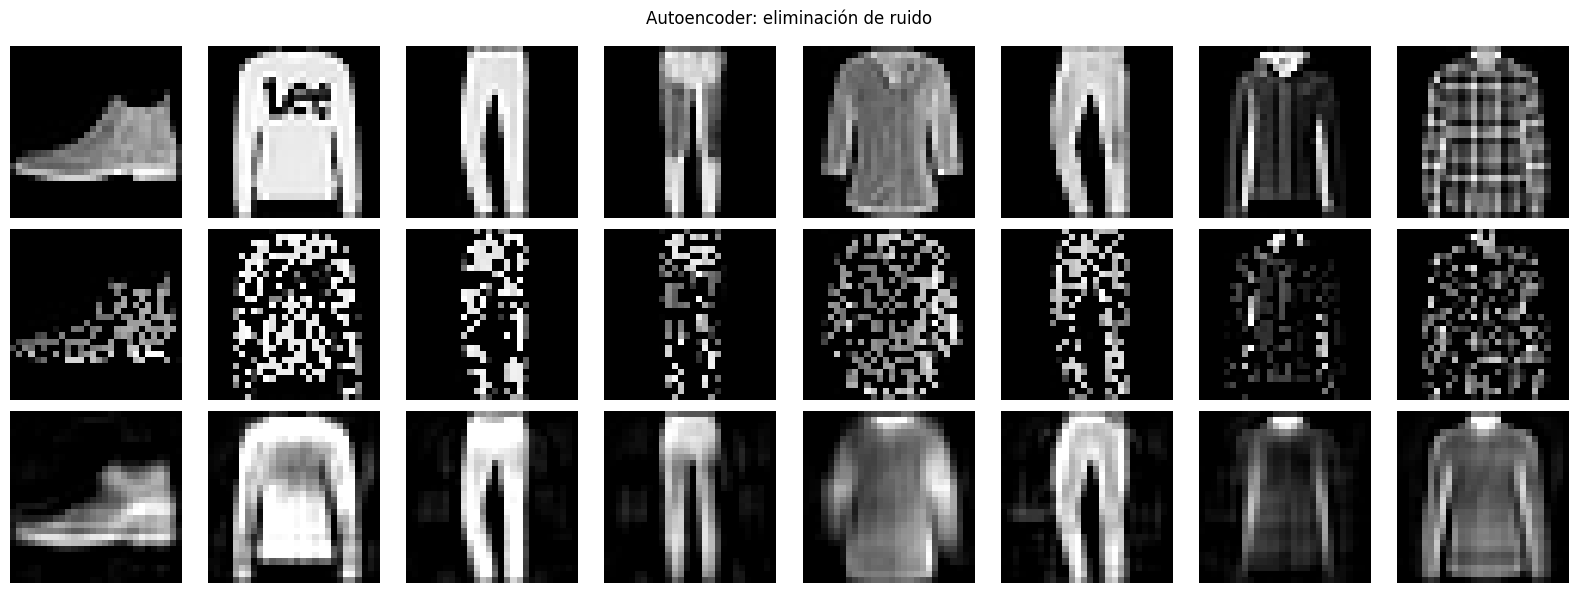

In [24]:

epochs = 50

# 1. Poné el modelo en modo entrenamiento
net_ae.train()

for epoch in range(epochs):
    loss_acumulada = 0

    # 2. Para cada lote del iter_train
    for images, _ in iter_train:

        # Objetivo: imagen original sin el canal (B, 28, 28)
        objetivo = images.squeeze(1)

        # Forward pass
        salida_ae = net_ae(images)
        loss = loss_ae(salida_ae, objetivo)

        # 4 pasos: zero_grad -> backward -> step
        trainer_ae.zero_grad()
        loss.backward()
        trainer_ae.step()

        loss_acumulada += loss.item()

    # Imprimimos progreso cada 5
    if (epoch + 1) % 5 == 0:
        print(f"epoch {epoch+1}/{epochs} - Loss: {loss_acumulada/len(iter_train):.4f}")


images_val, _ = next(iter(iter_valid))


plot_reconstructions(net_ae, images_val)


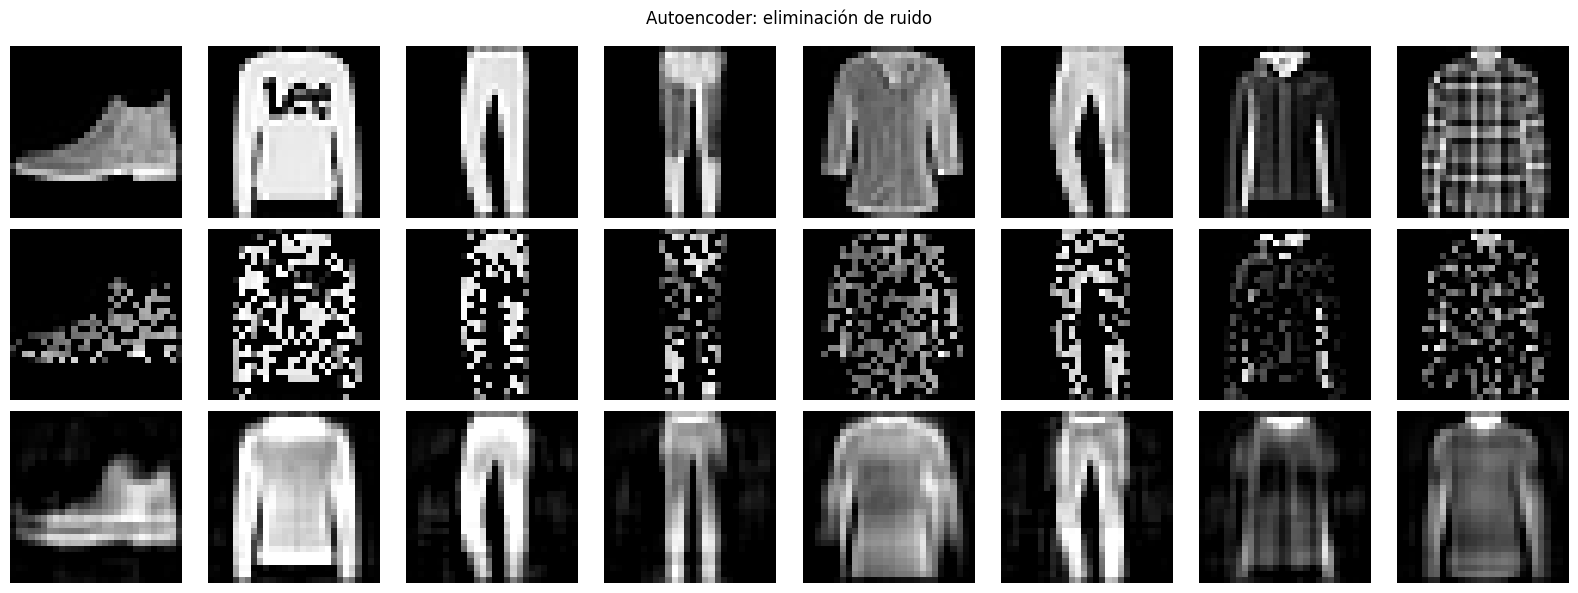

In [23]:
# Visualización de reconstrucciones — ejecutar sin modificar
import numpy as np

def plot_reconstructions(model, images, n=8):
    """
    Muestra imágenes originales, con ruido y reconstruidas por el modelo.

    Parámetros:
    model: el autoencoder entrenado (net_ae)
    images: lote de imágenes sin ruido
    n: número de imágenes a mostrar
    """
    # Generamos ruido externamente (para poder mostrarlo)
    ruido = nn.Sequential(nn.Dropout(0.5))
    ruido.train()
    noisy = ruido(images[:n])

    # En eval(), el Dropout del modelo está desactivado —
    # equivale a saltearse el bloque noise del autoencoder.
    # Pasamos la imagen ruidosa directamente al modelo completo.
    model.eval()
    with torch.no_grad():
        # La salida del decoder tiene forma (batch, 784); la
        # clipeamos a [0,1] y le damos forma (batch, 28, 28).
        recon_flat = model(noisy)
        recon = np.clip(recon_flat.detach().numpy(), 0, 1).reshape(-1, 28, 28)
    model.train()

    fig, axes = plt.subplots(3, n, figsize=(n * 2, 6))
    for i in range(n):
        axes[0, i].imshow(images[i].squeeze(), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(noisy[i].squeeze().detach(), cmap="gray")
        axes[1, i].axis("off")
        axes[2, i].imshow(recon[i], cmap="gray")
        axes[2, i].axis("off")
    axes[0, 0].set_ylabel("Original", fontsize=11)
    axes[1, 0].set_ylabel("Con ruido", fontsize=11)
    axes[2, 0].set_ylabel("Reconstruida", fontsize=11)
    plt.suptitle("Autoencoder: eliminación de ruido")
    plt.tight_layout()
    plt.show()

images_val, _ = next(iter(iter_valid))
plot_reconstructions(net_ae, images_val)

### Ejercicio 6 — Ruido gaussiano con un módulo personalizado

**Objetivo:** Reemplazar el bloque `noise` (basado en Dropout) por un módulo personalizado que agregue ruido gaussiano, usando herencia de `nn.Module`.

**Enunciado:**

El **ruido gaussiano** agrega a cada píxel un valor aleatorio extraído de una distribución normal — en lugar de apagarlo como hace Dropout. Esto simula mejor el ruido de cámaras o sensores reales.

El ruido solo debe aplicarse durante el entrenamiento: cuando `self.training == True`. Durante la evaluación, las imágenes deben pasar sin modificación.

> **Pistas:**
> - Creá una clase `GaussianNoise(nn.Module)` con parámetros `mean` y `std`.
> - En el método `forward`, verificá `self.training` para decidir si aplicar ruido.
> - El ruido gaussiano se genera con `torch.randn_like(tensor) * std + mean`.
> - Re-ensamblar el autoencoder con este nuevo bloque y re-entrenarlo.

In [20]:

class GaussianNoise(nn.Module):
    def __init__(self, mean=0.0, std=0.1):
        super().__init__()
        self.mean = mean
        self.std = std

    def forward(self, x):
        # El ruido solo se aplica si el modelo está en modo .train()
        if self.training:
            noise = torch.randn_like(x) * self.std + self.mean
            return torch.clamp(x + noise, 0, 1)
        return x

# Re-ensamblar el autoencoder con el nuevo bloque
net_ae = nn.Sequential(
    GaussianNoise(mean=0.0, std=0.2),
    encoder,
    decoder
)


**Pregunta de análisis:**

¿En qué se diferencia el ruido de Dropout del ruido gaussiano visualmente y conceptualmente? ¿Cuál te parece más realista para eliminar ruido en imágenes naturales?

Visual y conceptualmente: El ruido de Dropout apaga píxeles al azar (los pone en negro), creando "agujeros" en la imagen. El ruido gaussiano suma variaciones aleatorias de intensidad a cada píxel, generando una textura granulada o "estática".

Realismo: El ruido gaussiano es mucho más realista para imágenes naturales. Esto se debe a que simula las imperfecciones electrónicas de los sensores de las cámaras y la interferencia en la captura de luz, mientras que el Dropout es un fenómeno artificial que rara vez ocurre en la realidad.

---
## Fin del Laboratorio 1c

Completaste el laboratorio sobre autoencoders. Ahora sabés cómo construir arquitecturas encoder-decoder para tareas de reconstrucción de señales.